<a href="https://colab.research.google.com/github/smozwald/foundation-flood/blob/main/notebooks/01_data_ingestion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Supabase and GEE connection.

We first need to connect GEE and Supabase, for handling our satellite imagery and for storing our data.


In [1]:
import google.colab.auth as auth
from google.cloud import bigquery

# 1. Authenticate User
auth.authenticate_user()

# 2. Define Project ID
project_id = 'foundation-flood'

# 3. Initialize BigQuery Client
client = bigquery.Client(project=project_id)

# Test Connection
query = "SELECT 'Connection Successful' as status"
client.query(query).to_dataframe()

,status
0,Connection Successful


# Supabase Creation
For our supabase, we want to capture data and metadata relating to the rivers in question, as well as each pixel and the data processing applied to it (to calculate flooded pixels). We will create these tables below if they do not exist, and may update them in future.
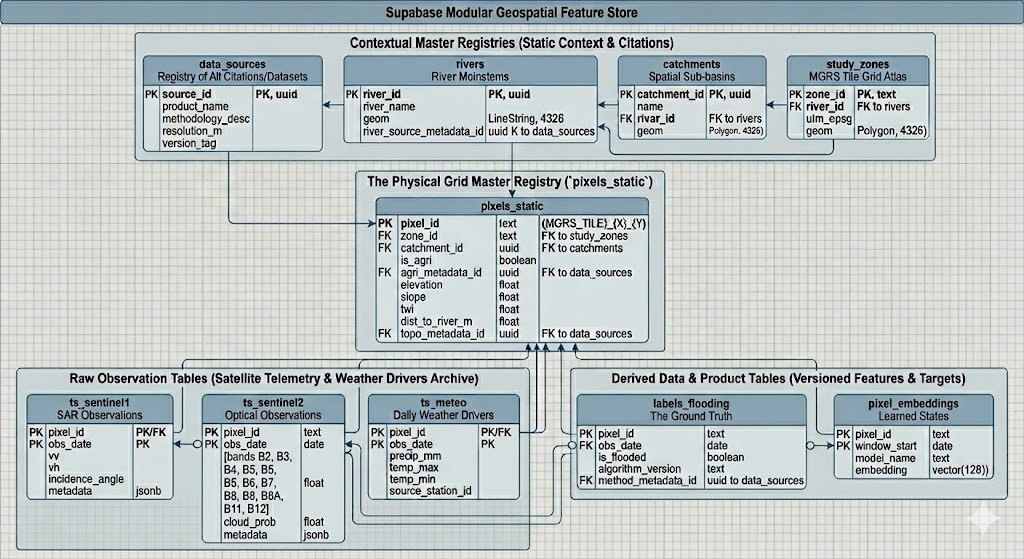

In [3]:
import psycopg2
from google.colab import userdata

# Retrieve the verified connection string
try:
    CONN_STRING = userdata.get('SUPABASE_CONN_STRING')
except Exception:
    print("Error: Secret 'SUPABASE_CONN_STRING' not found in the Secrets tab.")


def initialize_database():
    """
    Creates the full Geospatial Feature Store schema from scratch.
    Safe to re-run: exits early if the anchor table already exists.
    """
    conn = None
    try:
        conn = psycopg2.connect(CONN_STRING)
        cur = conn.cursor()

        cur.execute("""
            SELECT EXISTS (
                SELECT FROM information_schema.tables
                WHERE table_schema = 'public'
                AND table_name = 'pixels_static'
            );
        """)
        if cur.fetchone()[0]:
            print("Status: Database schema already exists. Run extend_database() to add new tables.")
            return

        print("Action: Creating Geospatial Feature Store...")

        cur.execute("CREATE EXTENSION IF NOT EXISTS postgis;")
        cur.execute("CREATE EXTENSION IF NOT EXISTS vector;")

        # ── 1. Contextual Master Registries ─────────────────────────────────────
        cur.execute("""
            CREATE TABLE IF NOT EXISTS data_sources (
                source_id        uuid PRIMARY KEY DEFAULT gen_random_uuid(),
                product_name     text NOT NULL,
                methodology_desc text,
                resolution_m     float,
                version_tag      text
            );

            CREATE TABLE IF NOT EXISTS rivers (
                river_id                 uuid PRIMARY KEY DEFAULT gen_random_uuid(),
                river_name               text NOT NULL,
                geom                     geometry(LineString, 4326),
                river_source_metadata_id uuid REFERENCES data_sources(source_id)
            );

            CREATE TABLE IF NOT EXISTS catchments (
                catchment_id uuid PRIMARY KEY DEFAULT gen_random_uuid(),
                name         text NOT NULL,
                river_id     uuid REFERENCES rivers(river_id),
                geom         geometry(Polygon, 4326)
            );
        """)

        # ── 2. Study Zones ───────────────────────────────────────────────────────
        # Each zone is a spatial tile (e.g. 2x2 km box) snapped to a river reach.
        # Tiles are generated along the river linestring at regular intervals
        # (one at the discharge station, one upstream, one downstream).
        # zone_id follows the pattern: MGRS_TILE_{X}_{Y} for GEE alignment.
        # position_label: 'at_station' | 'upstream' | 'downstream'
        cur.execute("""
            CREATE TABLE IF NOT EXISTS study_zones (
                zone_id          text PRIMARY KEY,              -- e.g. 32UNC_120_344
                river_id         uuid REFERENCES rivers(river_id),
                catchment_id     uuid REFERENCES catchments(catchment_id),
                geom             geometry(Polygon, 4326),       -- the tile polygon
                centroid         geometry(Point, 4326),         -- for fast spatial joins
                tile_size_m      float NOT NULL DEFAULT 2000,   -- tile edge length in metres
                position_label   text CHECK (position_label IN (
                                     'at_station', 'upstream', 'downstream', 'other'
                                 )),
                distance_m_along_river float,                   -- metres along linestring from station
                ulm_epsg         integer                        -- local UTM EPSG for area calculations
            );
            CREATE INDEX IF NOT EXISTS study_zones_geom_idx
                ON study_zones USING GIST (geom);
            CREATE INDEX IF NOT EXISTS study_zones_river_idx
                ON study_zones (river_id);
        """)

        # ── 3. Physical Grid Master Registry ────────────────────────────────────
        cur.execute("""
            CREATE TABLE IF NOT EXISTS pixels_static (
                pixel_id         text PRIMARY KEY,              -- MGRS_TILE_{X}_{Y}
                zone_id          text REFERENCES study_zones(zone_id),
                catchment_id     uuid REFERENCES catchments(catchment_id),
                is_agri          boolean,
                agri_metadata_id uuid REFERENCES data_sources(source_id),
                elevation        float,
                slope            float,
                twi              float,                         -- Topographic Wetness Index
                spi              float,                         -- Stream Power Index
                curvature        float,                         -- plan curvature
                dist_to_river_m  float,
                topo_metadata_id uuid REFERENCES data_sources(source_id)
            );
            CREATE INDEX IF NOT EXISTS pixels_static_zone_idx
                ON pixels_static (zone_id);
        """)

        # ── 4. Raw Observation Tables ────────────────────────────────────────────
        cur.execute("""
            CREATE TABLE IF NOT EXISTS ts_sentinel1 (
                pixel_id         text REFERENCES pixels_static(pixel_id),
                obs_date         date NOT NULL,
                vv               float,
                vh               float,
                incidence_angle  float,
                metadata         jsonb,
                PRIMARY KEY (pixel_id, obs_date)
            );

            CREATE TABLE IF NOT EXISTS ts_sentinel2 (
                pixel_id         text REFERENCES pixels_static(pixel_id),
                obs_date         date NOT NULL,
                b2 float, b3 float, b4 float,  b5 float,  b6 float,
                b7 float, b8 float, b8a float, b11 float, b12 float,
                cloud_prob       float,
                metadata         jsonb,
                PRIMARY KEY (pixel_id, obs_date)
            );

            CREATE TABLE IF NOT EXISTS ts_meteo (
                pixel_id         text REFERENCES pixels_static(pixel_id),
                obs_date         date NOT NULL,
                precip_mm        float,
                temp_max         float,
                temp_min         float,
                source_station_id text,
                PRIMARY KEY (pixel_id, obs_date)
            );
        """)

        # ── 5. Derived Data & Product Tables ────────────────────────────────────
        cur.execute("""
            CREATE TABLE IF NOT EXISTS labels_flooding (
                pixel_id            text REFERENCES pixels_static(pixel_id),
                obs_date            date NOT NULL,
                is_flooded          boolean,
                algorithm_version   text,
                method_metadata_id  uuid REFERENCES data_sources(source_id),
                event_id            uuid,                       -- FK added after flood_events is created
                PRIMARY KEY (pixel_id, obs_date)
            );

            CREATE TABLE IF NOT EXISTS pixel_embeddings (
                pixel_id         text REFERENCES pixels_static(pixel_id),
                window_start     date NOT NULL,
                model_name       text NOT NULL,
                embedding        vector(128),
                PRIMARY KEY (pixel_id, window_start, model_name)
            );
        """)

        conn.commit()
        print("Success: Core schema initialized. Now running extend_database() for DFO tables...")
        conn.close()
        conn = None
        extend_database()

    except Exception as e:
        print(f"Error during initialization: {e}")
        if conn:
            conn.rollback()
    finally:
        if conn:
            conn.close()


def extend_database():
    """
    Appends the three DFO hydrological tables to an already-initialized schema.
    Safe to re-run: uses IF NOT EXISTS throughout and checks for the anchor
    table (discharge_stations) before doing anything.
    """
    conn = None
    try:
        conn = psycopg2.connect(CONN_STRING)
        cur = conn.cursor()

        # Guard: don't re-run if already extended
        cur.execute("""
            SELECT EXISTS (
                SELECT FROM information_schema.tables
                WHERE table_schema = 'public'
                AND table_name = 'discharge_stations'
            );
        """)
        if cur.fetchone()[0]:
            print("Status: DFO extension tables already exist. No action taken.")
            return

        print("Action: Adding DFO hydrological tables...")

        # ── A. discharge_stations ────────────────────────────────────────────────
        # One row per DFO virtual gauging station.
        # A station belongs to a catchment. It is *placed within* one study zone
        # (position_label = 'at_station'). All other zones in the catchment carry
        # a NULL station_id — this is the "0 for zones where no station" pattern.
        cur.execute("""
            CREATE TABLE IF NOT EXISTS discharge_stations (
                station_id       uuid PRIMARY KEY DEFAULT gen_random_uuid(),

                -- DFO source identifiers
                dfo_station_id   text UNIQUE NOT NULL,          -- e.g. '000257'
                station_name     text,

                -- Spatial placement
                geom             geometry(Point, 4326) NOT NULL,
                catchment_id     uuid REFERENCES catchments(catchment_id),

                -- The one study_zone where this station sits (at_station tile).
                -- Other zones in the same catchment reference this station as NULL.
                zone_id          text REFERENCES study_zones(zone_id),

                -- River linkage
                river_id         uuid REFERENCES rivers(river_id),

                -- Record provenance
                source_id        uuid REFERENCES data_sources(source_id),
                record_start     date,                          -- earliest date in DFO archive
                record_end       date                           -- NULL if still active
            );

            CREATE INDEX IF NOT EXISTS discharge_stations_geom_idx
                ON discharge_stations USING GIST (geom);
            CREATE INDEX IF NOT EXISTS discharge_stations_catchment_idx
                ON discharge_stations (catchment_id);
        """)

        # ── B. discharge_ts ──────────────────────────────────────────────────────
        # Daily discharge time series downloaded from the DFO CSV archive.
        # threshold_exceeded_category stores the DFO flood category (1–5) on
        # days when discharge exceeds the 2-year return-period threshold,
        # NULL on normal days. This lets you query flood days without joining
        # flood_thresholds on every row.
        cur.execute("""
            CREATE TABLE IF NOT EXISTS discharge_ts (
                station_id                uuid REFERENCES discharge_stations(station_id),
                obs_date                  date NOT NULL,

                discharge_m3s             float,               -- raw DFO value (m³/s)
                discharge_anomaly_pct     float,               -- % above/below long-term mean

                -- Denormalised threshold flag (saves a join in the ML pipeline)
                -- NULL  → normal flow
                -- 1     → 1.5–2 yr return period  (DFO 'Minor')
                -- 2     → 2–5 yr                  (DFO category 2)
                -- 3     → 5–10 yr                 (DFO category 3)
                -- 4     → 10–20 yr                (DFO category 4)
                -- 5     → 20+ yr                  (DFO 'Major')
                threshold_exceeded_category smallint CHECK (threshold_exceeded_category BETWEEN 1 AND 5),

                qc_flag                   text,                -- 'ok' | 'interpolated' | 'suspect'
                source_id                 uuid REFERENCES data_sources(source_id),

                PRIMARY KEY (station_id, obs_date)
            );

            CREATE INDEX IF NOT EXISTS discharge_ts_station_date_idx
                ON discharge_ts (station_id, obs_date DESC);
            CREATE INDEX IF NOT EXISTS discharge_ts_flooded_idx
                ON discharge_ts (station_id)
                WHERE threshold_exceeded_category IS NOT NULL;
        """)

        # ── C. flood_thresholds ──────────────────────────────────────────────────
        # Five threshold rows per station, matching DFO's return-period categories.
        # The agent populates these from the graph/table on each station's DFO page.
        # Used by the flood-event detection pipeline and by discharge_ts backfill.
        cur.execute("""
            CREATE TABLE IF NOT EXISTS flood_thresholds (
                threshold_id     uuid PRIMARY KEY DEFAULT gen_random_uuid(),
                station_id       uuid REFERENCES discharge_stations(station_id) NOT NULL,

                -- DFO return-period category (1 = lowest, 5 = highest)
                category         smallint NOT NULL CHECK (category BETWEEN 1 AND 5),

                -- Human-readable label matching DFO website
                -- e.g. '1.5-2 yr', '2-5 yr', '5-10 yr', '10-20 yr', '20+ yr'
                return_period_label text NOT NULL,

                -- Discharge value in m³/s at which this category begins
                discharge_threshold_m3s float NOT NULL,

                derived_from     text DEFAULT 'DFO_station_page',
                valid_from       date,                         -- NULL = applies to full record
                valid_to         date,

                UNIQUE (station_id, category)
            );
        """)

        # ── D. flood_events ──────────────────────────────────────────────────────
        # One row per detected flood event at a station.
        # Events are derived: the pipeline scans discharge_ts for consecutive days
        # above category-1 threshold and collapses them into events.
        # dfo_archive_id links back to the DFO active-archive event catalogue
        # (optional — not all DFO catalogue events have matched station readings).
        cur.execute("""
            CREATE TABLE IF NOT EXISTS flood_events (
                event_id             uuid PRIMARY KEY DEFAULT gen_random_uuid(),
                station_id           uuid REFERENCES discharge_stations(station_id) NOT NULL,
                river_id             uuid REFERENCES rivers(river_id),
                catchment_id         uuid REFERENCES catchments(catchment_id),

                -- Temporal bounds (inclusive)
                flood_start          date NOT NULL,
                flood_end            date NOT NULL,
                duration_days        integer GENERATED ALWAYS AS
                                     (flood_end - flood_start + 1) STORED,

                -- Severity
                peak_discharge_m3s   float,
                peak_date            date,
                max_category         smallint CHECK (max_category BETWEEN 1 AND 5),

                -- Cross-reference to DFO active-archive catalogue (optional)
                dfo_archive_id       text,

                -- Provenance / QC
                detection_method     text DEFAULT 'threshold_exceedance',
                notes                text,

                CONSTRAINT valid_dates CHECK (flood_end >= flood_start)
            );

            CREATE INDEX IF NOT EXISTS flood_events_station_idx
                ON flood_events (station_id);
            CREATE INDEX IF NOT EXISTS flood_events_dates_idx
                ON flood_events (flood_start, flood_end);
            CREATE INDEX IF NOT EXISTS flood_events_catchment_idx
                ON flood_events (catchment_id);
        """)

        # ── E. Add event_id column + FK to labels_flooding ──────────────────────
        # The original schema didn't have event_id at all, so we must ADD the
        # column before we can attach a FK constraint. Both steps are guarded
        # independently so the block is safe to re-run.
        cur.execute("""
            DO $$
            BEGIN
                -- Step 1: add the column if it doesn't exist yet
                IF NOT EXISTS (
                    SELECT 1 FROM information_schema.columns
                    WHERE table_schema  = 'public'
                    AND   table_name    = 'labels_flooding'
                    AND   column_name   = 'event_id'
                ) THEN
                    ALTER TABLE labels_flooding
                        ADD COLUMN event_id uuid;
                END IF;

                -- Step 2: add the FK constraint if it doesn't exist yet
                IF NOT EXISTS (
                    SELECT 1 FROM information_schema.table_constraints
                    WHERE constraint_schema = 'public'
                    AND   constraint_name   = 'labels_flooding_event_id_fkey'
                ) THEN
                    ALTER TABLE labels_flooding
                        ADD CONSTRAINT labels_flooding_event_id_fkey
                        FOREIGN KEY (event_id)
                        REFERENCES flood_events(event_id);
                END IF;
            END $$;
        """)

        # ── F. Add station_id to study_zones (optional back-reference) ───────────
        # Lets you query "which zones have a station" with a simple IS NOT NULL.
        cur.execute("""
            DO $$
            BEGIN
                IF NOT EXISTS (
                    SELECT 1 FROM information_schema.columns
                    WHERE table_name  = 'study_zones'
                    AND   column_name = 'station_id'
                ) THEN
                    ALTER TABLE study_zones
                        ADD COLUMN station_id uuid
                        REFERENCES discharge_stations(station_id);
                    COMMENT ON COLUMN study_zones.station_id IS
                        'NULL for upstream/downstream tiles; set only for the at_station tile.';
                END IF;
            END $$;
        """)

        conn.commit()
        print("Success: DFO hydrological extension tables created.")
        print()
        print("Tables added:")
        print("  discharge_stations  — one row per DFO virtual gauge")
        print("  discharge_ts        — daily discharge time series (with denormed threshold flag)")
        print("  flood_thresholds    — 5 return-period thresholds per station from DFO page")
        print("  flood_events        — derived flood episodes (start/end/peak/category)")
        print()
        print("Schema changes to existing tables:")
        print("  labels_flooding.event_id  — FK now wired to flood_events")
        print("  study_zones.station_id    — NULL for off-station tiles, set for at_station tile")

    except Exception as e:
        print(f"Error during extension: {e}")
        if conn:
            conn.rollback()
    finally:
        if conn:
            conn.close()


if __name__ == "__main__":
    # Run both in sequence. Each function is idempotent — safe to re-run.
    initialize_database()  # creates core schema (exits early if already exists)
    extend_database()       # appends DFO tables    (exits early if already exists)

Status: Database schema already exists. Run extend_database() to add new tables.
Action: Adding DFO hydrological tables...
Success: DFO hydrological extension tables created.

Tables added:
  discharge_stations  — one row per DFO virtual gauge
  discharge_ts        — daily discharge time series (with denormed threshold flag)
  flood_thresholds    — 5 return-period thresholds per station from DFO page
  flood_events        — derived flood episodes (start/end/peak/category)

Schema changes to existing tables:
  labels_flooding.event_id  — FK now wired to flood_events
  study_zones.station_id    — NULL for off-station tiles, set for at_station tile


# Collect Our Sample River

The key thing we need is a river where we have a number of known floods over the period we wish to investigate.

The Dnester River in Eastern Europe may be pertinent due to past flooding in our study period.  See https://floodobservatory.colorado.edu/wiki/Discharge:Station_000257

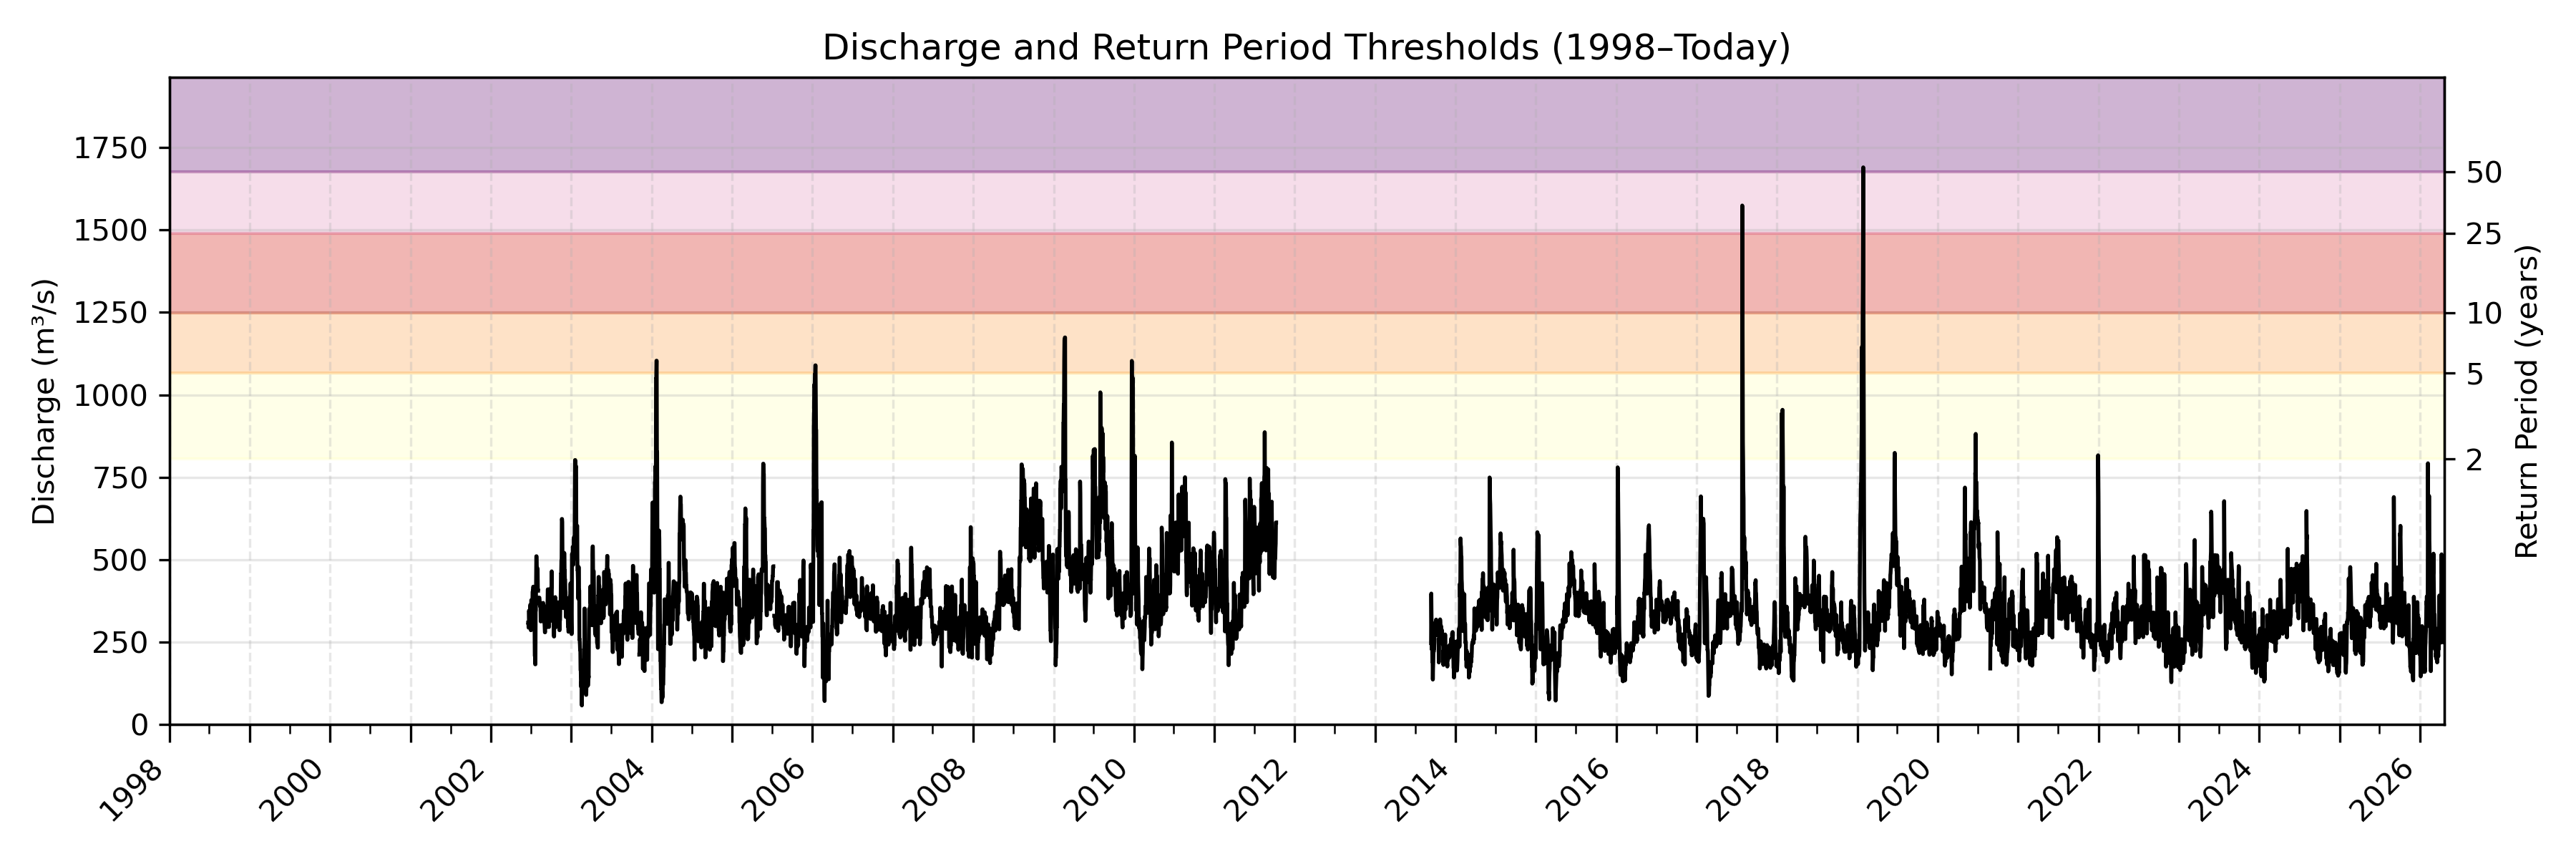

Pale Yellow: Changes at 800 $m^3/s$ (This marks the 2-year return period).
Light Orange: Changes at 1,050 $m^3/s$ (The 5-year return period).Pink/Red: Changes at 1,250 $m^3/s$ (The 10-year return period).
Light Purple: Changes at 1,500 $m^3/s$ (The 25-year return period).
Dark Purple: Changes at 1,650 $m^3/s$ (The 50-year return period).

# Collect Sentinel-1 Data with GEE

In this step we collect our Sentinel-1 data. Use this as a starter guide https://www.youtube.com/watch?v=c3_UlwEwEoE

We need to keep in mind some key points. VH = Good for detecting open water flood (rivers, lakes), VV=Good for agriculture. We should also colelct annual land cover maps in the area to better account for these.

1. Collect our standard annual pixels
2. Speckle Noise reduction function, to process our data. Need to further check what the best values are for smoothing this noise.
3. Collect SAR values over season (including 1 indicating pre-flood at least, possible select depending on how much data we need). We need to use Sentinel-1 GRD → RTC (Radiometric Terrain Corrected). (OR Sentinel-1 NRB?)
4. Store these values in Supabase.
5.OTSU Thresholding (or other thresholding) to indicate water presence throughout season on agriculture pixels. Basically based on difference with when the pixel is non-flooded, we choose a cutoff to state if it is flooded or not.